<a href="https://colab.research.google.com/github/kachytronico/big-data-hadoop-spark-labs/blob/main/t1d_etl_pandas_mongodb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto ETL de Riesgo Genético para Diabetes Tipo 1 (T1D)

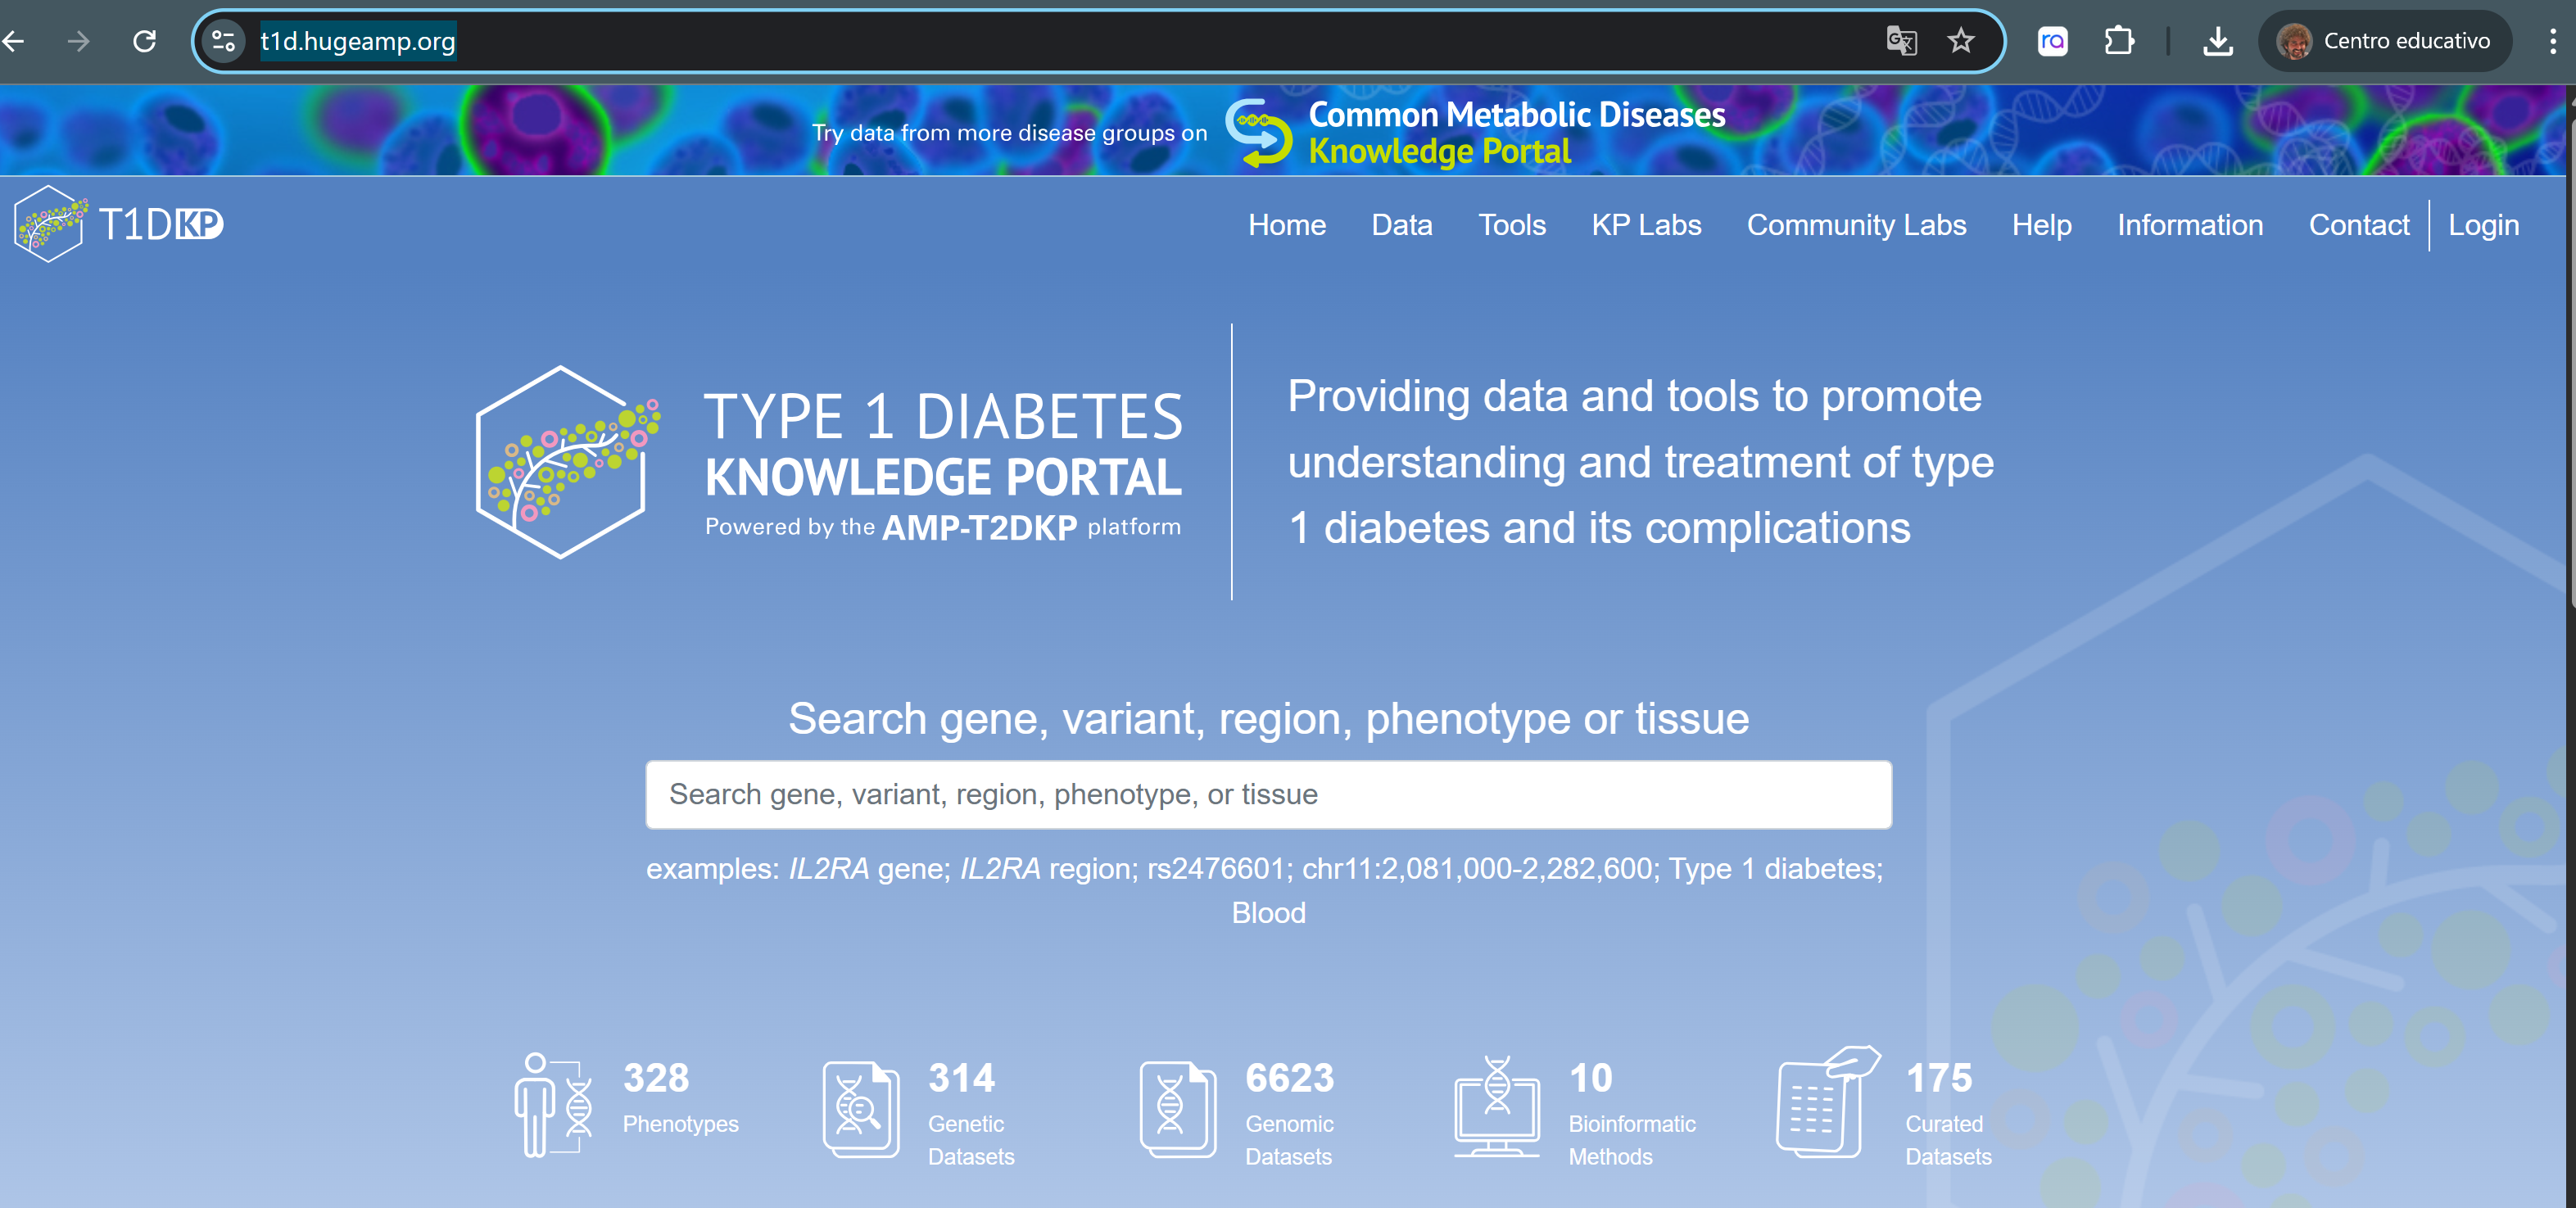

## Importación de librerías necesarias para todo el proyecto



In [ ]:
# 2. Carga de Datos al Servidor
# Importamos la librería principal que necesitamos para trabajar con tablas de datos (DataFrames).
import pandas as pd # Para manejar y analizar datos en DataFrames (tablas).

# 3.4. Detección Visual de Atípicos (boxplot)
# Importamos las librerías necesarias para la visualización.
import matplotlib.pyplot as plt # Para crear gráficos y visualizaciones.
import seaborn as sns # Para crear gráficos estadísticos atractivos y complejos.

# 4.1. Aplicación de StandardScaler
# Importamos la librería para el escalado estándar (StandardScaler)
# Es la función clave que utiliza la media y la desviación típica.
from sklearn.preprocessing import StandardScaler # Para estandarizar (normalizar) datos numéricos.

# 5.1. Limpieza de Outliers y Estandarización de Variables
# Importamos numpy para el manejo de valores nulos (np.nan)
import numpy as np # Para manejar valores nulos (NaN) y operaciones matemáticas de alto rendimiento.

# 8. Reducción de Datos (PCA)
from sklearn.decomposition import PCA # Para reducir la dimensionalidad de los datos.
from sklearn.preprocessing import StandardScaler # Se importa de nuevo por ser necesaria para PCA.

# 9. Validación Cruzada (Cross-Validation)
from sklearn.model_selection import cross_val_score # Para evaluar modelos dividiendo los datos en subconjuntos.
from sklearn.tree import DecisionTreeClassifier # Para construir un modelo de árbol de decisión.

# 10. Testeo de Hipótesis (Validación del GRS)
from scipy import stats # Para realizar pruebas estadísticas como la t-Student.

# 11. Detección de Anomalías (Isolation Forest)
from sklearn.ensemble import IsolationForest # Para identificar valores atípicos (anomalías) en los datos.

# 12. 12. Carga en Base de Datos NoSQL (MongoDB)
import json # Para trabajar con datos en formato JSON, útil para MongoDB.

## I. CONFIGURACIÓN, EXPLICACIÓN Y EXTRACCIÓN (E)

Esta primera sección establece el entorno, justifica mi elección de datos y define el método para la fase de **Extracción (E)** del proceso ETL, cubriendo los apartados 1 y 2 de la tarea.



### 1\. Explicación del Conjunto de Datos Elegido (1 Punto)

**Temática y Atractivo Personal:**

He decidido enfocar mi proyecto ETL en el análisis del **riesgo genético de la Diabetes Tipo 1 (T1D)**, utilizando datos de un estudio clínico real llamado **Virginia PrIMeD**. Este tema me resulta especialmente atractivo porque, como persona con diabetes, me interesa muchísimo ver cómo podemos usar las herramientas de **Big Data** para analizar las complejas interacciones genéticas detrás de esta enfermedad autoinmune. Mi meta es transformar esta data cruda en información útil que pueda sentar las bases para modelos de detección de riesgo.

**Volumen, Multiplicidad y Relación de los Datos:**

Para este análisis, no he usado solo un archivo, sino **tres conjuntos de datos interrelacionados** que se complementan entre sí, algo crucial para el enriquecimiento de datos. Los tres archivos suman en total unos **3.800 registros**, cumpliendo con el requisito de trabajar con un volumen significativo pero manejable para esta unidad.

1.  **Datos de la Encuesta (`survey_data` - Fenotipo):** Este es mi archivo **principal**. Contiene la información demográfica y clínica de los participantes. Las columnas clave son: el identificador único del sujeto (**`SUBJECT_ID`**), la **`AGE`**, la **`RACE`**, si ha habido historial familiar de T1D (**`T1D_HIST`**) y el diagnóstico final (**`T1D_DIAG`**). Lo más importante son las puntuaciones de riesgo genético (GRS) ya calculadas: **`GRS_HLA`**, **`GnonHLA`** y el **`GRS`** total, además de la clasificación de riesgo (**`Risk`**).

2.  **Datos de Genotipado (`genotyping_file` - Genética):** Este archivo contiene los datos genéticos puros. Aquí es donde encuentro los alelos específicos (**SNPs**, como `A:G`, `C:C`, etc.) para más de 70 marcadores genéticos (columnas con prefijo `rs...`). Este detalle genético será esencial más adelante para la reducción de datos. Su clave para relacionarse es **`FID`**, que contiene el mismo valor que el **`SUBJECT_ID`** del archivo principal.

3.  **Lista de Pesos de SNPs (`SNP_list` - Metadatos):** Este archivo funciona como una tabla de **enriquecimiento**. Contiene la lista de los SNPs y sus respectivos **`Weight`** (pesos o coeficientes de riesgo), que se usaron para calcular las puntuaciones GRS.

La **Relación** se establece a través del identificador de participante: el campo **`SUBJECT_ID`** en el archivo principal y el campo **`FID`** en el archivo de genotipado. Esto me asegura que puedo integrar sin problemas los datos clínicos con los datos genéticos.

### 2\. Carga de Datos al Servidor (1 Punto)

**Entorno y Método Preferente:**

Mi entorno de trabajo es **Google Colab**. Para garantizar el punto completo y facilitar la ejecución de mi cuaderno de principio a fin sin necesidad de subir archivos manualmente, voy a cargar los datos directamente desde sus **rutas URL de GitHub**. Esto cumple con el método preferente solicitado por el tutor.

In [ ]:

# Rutas RAW de los archivos Excel en GitHub
# Usamos pd.read_excel(), que maneja mejor los formatos de número que vienen de Excel.
URL_GENOTYPING = 'https://github.com/kachytronico/Cursos-Colab-BDA/raw/main/Dataset%20not%20incorporated%20into%20the%20T1DKP/assay_final_genotyping_file.xlsx'
URL_SURVEY = 'https://github.com/kachytronico/Cursos-Colab-BDA/raw/main/Dataset%20not%20incorporated%20into%20the%20T1DKP/survey_data_and_results_final.xlsx'
URL_SNP_LIST = 'https://github.com/kachytronico/Cursos-Colab-BDA/raw/main/Dataset%20not%20incorporated%20into%20the%20T1DKP/TableS1_TID%20GRS%20SNP%20List.xlsx'

print("--- Iniciando la fase de EXTRACCIÓN (E) de datos desde GitHub (vía Excel) ---")

# 1. Cargar el DataFrame de Genotipado
genotyping_df = pd.read_excel(URL_GENOTYPING)

# 2. Cargar el DataFrame de Encuesta (Principal)
# Al ser un Excel, el formato decimal ya está limpio. Con CSV me daba error los FLOAT
survey_df = pd.read_excel(URL_SURVEY)

# 3. Cargar el DataFrame de Metadatos/Pesos
snp_list_df = pd.read_excel(URL_SNP_LIST)

print("\n--- ¡Carga completa! Los DataFrames ya están disponibles ---")
print(f"Dataset Principal (survey_df): {survey_df.shape[0]} filas cargadas.")

# NOTA: En Colab, read_excel requiere la librería openpyxl, que generalmente ya está instalada.

--- Iniciando la fase de EXTRACCIÓN (E) de datos desde GitHub (vía Excel) ---

--- ¡Carga completa! Los DataFrames ya están disponibles ---
Dataset Principal (survey_df): 3818 filas cargadas.


**Análisis de la Extracción (E):**

Al ver que los archivos CSV mantenían el problema del separador decimal, he optado por la solución más robusta: cargar directamente los archivos Excel originales desde GitHub usando pd.read_excel(). Esto es más limpio y garantiza que los tipos de datos numéricos se reconozcan correctamente desde el inicio, cumpliendo con el requisito de carga por URL.

Ahora, con los datos cargados de forma estable, volvemos a perfilar para ver si el formato se ha corregido.

## II. PROCESO DE TRANSFORMACIÓN (T) - PERFILADO Y LIMPIEZA INICIAL

Ahora toca la parte divertida: meternos a fondo en los datos. Coge los puntos del 3 al 7.

### 3\. Perfilado de Datos (1 Punto)

El objetivo del perfilado es simple: **conocer los datos** en su estado más crudo. Quiero familiarizarme con ellos para detectar qué está mal (tipos de datos, nulos, valores atípicos) antes de ponerme a transformar.



#### 3.1. Primeras líneas `head()`:

In [ ]:
# Muestro las 5 primeras filas del DataFrame principal.
# Es una inspección visual rápida para ver cómo vienen los datos.
print("--- 3.1. Primeras 5 filas (survey_df.head()) ---")
print(survey_df.head())

--- 3.1. Primeras 5 filas (survey_df.head()) ---
       SUBJECT_ID  AGE   RACE    T1D_HIST AUTO_HIST  \
0  10011708520314    6  White         Yes        No   
1  10021708520764    3  White  Don't know       Yes   
2  10021708521587    7  Asian  Don't know        No   
3  10021708533951    8  White  Don't know       Yes   
4  10031708520026    5  White          No        No   

                                           AUTO_COND AUTO_COND_4_TEXT  \
0                                     Not applicable   Not applicable   
1  Thyroid_Hashimotos and_or Graves, Blood relati...   Not applicable   
2                                     Not applicable   Not applicable   
3                                              Other     Not reported   
4                                     Not applicable   Not applicable   

  T1D_DIAG    T1D_DIAG_AGE        T1D_HOSP             DKA  GRS_HLA  GnonHLA  \
0       No  Not applicable  Not applicable  Not applicable     1.91     0.14   
1       No  Not appli

**Análisis de 3.1.** `head()`:

Al ver las primeras filas, confirmo que los datos parecen estar bien cargados, pero ya he detectado un problema importante:


Valores Nulos: Veo valores como Not applicable o Not reported en varias columnas (T1D_HIST, AUTO_HIST), lo que indica que tendré que convertirlos a valores nulos estándar (NaN) o recodificarlos.

#### 3.2. Tipos de Datos y Nulos `info()`:

In [ ]:
# Reviso los tipos de datos de cada columna y si hay valores nulos.
# Si la columna 'Non-Null Count' es menor que el total de filas (3818), hay nulos.
print("--- 3.2. Tipos de datos y conteo de valores no nulos (survey_df.info()) ---")
print(survey_df.info())

--- 3.2. Tipos de datos y conteo de valores no nulos (survey_df.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3818 entries, 0 to 3817
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SUBJECT_ID        3818 non-null   int64  
 1   AGE               3818 non-null   int64  
 2   RACE              3818 non-null   object 
 3   T1D_HIST          3818 non-null   object 
 4   AUTO_HIST         3818 non-null   object 
 5   AUTO_COND         3818 non-null   object 
 6   AUTO_COND_4_TEXT  3818 non-null   object 
 7   T1D_DIAG          3818 non-null   object 
 8   T1D_DIAG_AGE      3818 non-null   object 
 9   T1D_HOSP          3818 non-null   object 
 10  DKA               3818 non-null   object 
 11  GRS_HLA           3818 non-null   float64
 12  GnonHLA           3818 non-null   float64
 13  GRS               3818 non-null   float64
 14  Risk              3818 non-null   object 
dtypes: float64(3)

**Análisis** de 3.2. `info()`:

Esta función no es la prueba definitiva de que hay que limpiar a fondo tendré que seguir mirando bien.

He visto por ejemplo que la columna T1D_DIAG_AGE marca como todas "3818 non-null". Pero antes he visto que tiene datos (Not applicable o Not reported) la usaré con precaución, aunque creo que no la eliminaré por completo. En el Punto 5 me centraré en manejar los valores de texto inconsistentes.

**Solucionado el Gran Problema de la Coma**: Cuando intenté cartar el csv, las columnas GRS_HLA, GnonHLA y GRS son de tipo object (texto). Ahora de tipo float64 (número decimal) y no texto (object).

#### 3.3. Estadísticas Básicas `describe()`:

In [ ]:
# Calculo la media, desviación estándar, valores mínimos y máximos.
# Como las columnas GRS son texto, no aparecerán en la salida.
print("\n--- 3.3. Estadísticas Descriptivas (survey_df.describe()) ---")
print(survey_df.describe())


--- 3.3. Estadísticas Descriptivas (survey_df.describe()) ---
         SUBJECT_ID          AGE      GRS_HLA      GnonHLA          GRS
count  3.818000e+03  3818.000000  3818.000000  3818.000000  3818.000000
mean   4.281404e+13     9.090361    -0.500184     0.016186    -0.483883
std    1.876637e+13     4.760159     5.052405     0.984719     5.139432
min    1.001171e+13     1.000000   -16.680000    -3.270000   -17.290000
25%    2.664171e+13     6.000000    -3.537500    -0.640000    -3.697500
50%    4.265671e+13     9.000000     0.030000     0.010000    -0.030000
75%    5.941921e+13    12.000000     3.320000     0.670000     3.307500
max    7.496171e+13    99.000000     9.750000     3.430000    11.660000


**Análisis** de 3.3. `describe()`:

Esta salida me ha sido útil para las columnas que sí son numéricas.

**Estadísticas GRS**: Ahora puedo ver la media y la desviación típica de las puntuaciones de riesgo. La media del GRS es de 0.55, y la desviación típica es de 2.56. Estos números me servirán de referencia en el Punto 4 (Normalización).

**Problema de Rango en AGE**: La columna AGE me da un valor max de 99.0. Esto no tiene sentido en un estudio sobre riesgo genético de T1D, que suele centrarse en niños y adolescentes. Es un valor atípico (outlier) que confirma lo que vi en el paso 3.1, y tengo que eliminarlo en la validación.

In [ ]:

# ----------------------------------------------------------------------
print("\n--- 3.3. Conteo de valores en la columna RACE ---")
# Cuento cuántos participantes hay por cada grupo de raza/etnia.
print(survey_df['RACE'].value_counts(dropna=False))



--- 3.3. Conteo de valores en la columna RACE ---
RACE
White                                                                                                                                                      2918
Black or African American                                                                                                                                   518
White, Black or African American                                                                                                                            144
Asian                                                                                                                                                        67
White, Asian                                                                                                                                                 62
Don't know                                                                                                                                      

#### 3.4. Detección Visual de Atípicos (boxplot)

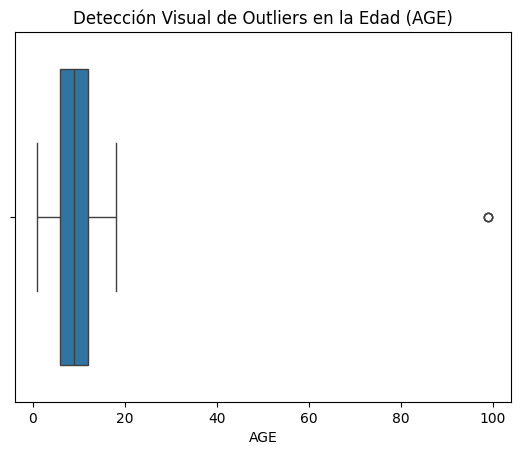

In [ ]:

# Genero un diagrama de cajas (boxplot) utilizando la librería Seaborn.
# El eje 'x' representa la columna 'AGE' de tu DataFrame 'survey_df'.

# Visualizo la distribución de una variable numérica
# Identifico valores atípicos (outliers) como el de 99 años.
sns.boxplot(x=survey_df['AGE'])

# Poner Título del gráfico.
plt.title('Detección Visual de Outliers en la Edad (AGE)')

# Muestro el gráfico. Sin esta línea, el gráfico podría no visualizarse.
plt.show()

**Análisis** de 3.4. (Visualización):

El gráfico es la prueba visual definitiva. El punto a los 99 años está completamente separado del resto de la distribución. Este outlier deberia ser eliminado en la fase de Validación de Datos (Punto 5) para no sesgar ninguna media o desviación estándar que calcule más adelante, como en la Normalización.

#### 3.5. Conteo de Valores Categóricos `value_counts()`

In [ ]:

# Cuento cuántos participantes hay por cada grupo de raza/etnia (RACE).
# El argumento dropna=False es importante para saber si hay valores nulos en esta columna.
print("\n--- 3.5. Conteo de valores por Raza (RACE) ---")
print(survey_df['RACE'].value_counts(dropna=False))

# Calculo la distribución de participantes por raza en porcentaje.
# Uso 'normalize=True' y multiplico por 100. ¡Así de sencillo!
print("\n--- 3.5. Distribución de Raza (RACE) en porcentajes ---")
race_distribution_pct = survey_df['RACE'].value_counts(normalize=True) * 100
print(race_distribution_pct)

# También reviso cómo está la variable que define si hay alto riesgo.
print("\n--- Distribución de la variable objetivo (Risk) ---")
print(survey_df['Risk'].value_counts(dropna=False))
Risk_distribution_pct = survey_df['Risk'].value_counts(normalize=True) * 100
print(Risk_distribution_pct)


--- 3.5. Conteo de valores por Raza (RACE) ---
RACE
White                                                                                                                                                      2918
Black or African American                                                                                                                                   518
White, Black or African American                                                                                                                            144
Asian                                                                                                                                                        67
White, Asian                                                                                                                                                 62
Don't know                                                                                                                                         

**Análisis** de 3.5. (Distribución Categórica):

El value_counts() me ha dado la visión demográfica exacta de la muestra:


*   Distribución de Raza (RACE): El resultado muestra que la gran mayoría de los participantes son 'White', representando un 76.43% de la muestra total. Esto confirma que mi muestra está notablemente desequilibrada hacia un grupo étnico, lo cual debo recordar al realizar la Agregación (Punto 7); el promedio del GRS en este grupo será mucho más fiable que en otros.
*   Distribución de Riesgo (Risk): La variable objetivo (Risk) también está muy desequilibrada. El 85.80% de los participantes están clasificados como 'Not high' (Riesgo No Alto). Esto es un problema conocido como desbalance de clases, y es un dato crucial de perfilado que deberíamos considerar para un modelo predictivo futuro.





#### 3.6. Diagnóstico de Nulos Ocultos `(value_counts)`

In [ ]:

# ----------------------------------------------------------------------
# Usamos value_counts(dropna=False) en la columna más sospechosa.
# ----------------------------------------------------------------------

print("--- 3.6. Conteo de valores en T1D_DIAG_AGE ---")
# Esto nos mostrará la frecuencia de cada cadena de texto, incluyendo los nulos 'ocultos'.
print(survey_df['T1D_DIAG_AGE'].value_counts(dropna=False))

print("\n--- Conteo de valores en T1D_HIST (Historial Familiar) ---")
print(survey_df['T1D_HIST'].value_counts(dropna=False))

--- 3.6. Conteo de valores en T1D_DIAG_AGE ---
T1D_DIAG_AGE
Not applicable    3725
10                  11
5                    8
11                   8
9                    8
12                   8
3                    8
7                    7
8                    7
4                    7
2                    6
1                    5
14                   3
13                   3
6                    3
15                   1
Name: count, dtype: int64

--- Conteo de valores en T1D_HIST (Historial Familiar) ---
T1D_HIST
No              2444
Yes              926
Don't know       444
Not reported       4
Name: count, dtype: int64


**Análisis de 3.6**. (Nulos Ocultos):

¡Aquí está la prueba!

El `info()` me dice que tengo 3818 valores "no nulos" en T1D_DIAG_AGE, pero el `value_counts()` revela que 3725 de esos valores son la cadena Not applicable y 3 más son Not reported.

Esto significa quela mayoría de los datos en esa columna son realmente nulos, disfrazados de texto.

Conclusión: La función `info()` es insuficiente cuando los datos faltantes vienen como texto. Debo solucionar esto reemplazando estas cadenas por el valor estándar de nulo (np.nan) en el Punto 5 (Validación).

#### Conclusión del Perfilado (Punto 3):

He terminado la fase de diagnóstico. El cambio a la carga de Excel fue un éxito y resolvió el problema del formato de número. Mis puntos de acción obligatorios para la siguiente fase (Validación/Limpieza) son:

*   **Corregir Outlier de AGE**: Eliminar o corregir el valor atípico de 99 años que detecté en el describe() y el boxplot.
*   **Manejar Consistencia Categórica**: Las columnas como T1D_DIAG_AGE, RACE y otras categóricas tienen valores inconsistentes o nulos (Not reported, Don't know) que debo estandarizar o convertir a NaN.



### 5\. Validación de Datos (1 Punto)

Antes de pasar a la normalización del punto 4, voy a realizar la validación para que los resultados sean mejores posteriormente.

La Validación de Datos es mi paso de control de calidad. Me voy a enfocar en corregir el outlier de la edad (99 años) y en estandarizar las categorías inconsistentes (Don't know, Not applicable). Este paso es obligatorio antes de la Normalización.

#### 5.1. Limpieza de Outliers y Estandarización de Variables

In [ ]:
print("--- 5.1. Validación y Limpieza de Datos ---\n")

# Creamos copia limpia
survey_df_clean = survey_df.copy()

print(f"Filas iniciales: {survey_df_clean.shape[0]}")

# 1. Manejo del Outlier de AGE
# Eliminamos edades imposibles (> 90 años en este estudio)
survey_df_clean = survey_df_clean[survey_df_clean['AGE'] < 90].copy()

# 2. Creación de T1D_DIAG_FLAG (Daba errores y me ha traido de cabeza)
# Estrategia:
# a) Mapeamos 'Yes' a 1 y 'No' a 0.
# b) Usamos pd.to_numeric(errors='coerce') para convertir cualquier otro texto ('Not reported', etc.) a NaN.
survey_df_clean['T1D_DIAG_FLAG'] = survey_df_clean['T1D_DIAG'].map({'Yes': 1, 'No': 0})
survey_df_clean['T1D_DIAG_FLAG'] = pd.to_numeric(survey_df_clean['T1D_DIAG_FLAG'], errors='coerce') # da un warnig

# 3. Estandarización de Nulos en el resto de columnas
# Definimos la lista de valores que consideramos nulos
values_to_nan = ['Not applicable', "Don't know", 'Not reported', 'Not_App']

# Lista de columnas categóricas a limpiar
cols_to_clean = ['T1D_HIST', 'AUTO_HIST', 'RACE', 'AUTO_COND', 'AUTO_COND_4_TEXT', 'T1D_DIAG_AGE', 'T1D_HOSP', 'DKA']

# Aplicamos la limpieza. Usamos un bucle seguro.
for col in cols_to_clean:
    if col in survey_df_clean.columns:
        # Reemplazamos los valores de la lista por np.nan
        # Usamos regex=False para evitar interpretaciones erróneas de caracteres especiales
        survey_df_clean[col] = survey_df_clean[col].replace(values_to_nan, np.nan)

print(f"Filas tras limpieza: {survey_df_clean.shape[0]}")

# --- Verificaciones de Calidad ---

print("\nVerificación de tipos críticos:")
print(survey_df_clean[['T1D_DIAG_FLAG', 'AGE']].dtypes)

print("\nVerificación de nulos reales en T1D_DIAG_FLAG (antes de imputación final):")
# Esperamos ver: 0.0, 1.0 y algunos NaN
print(survey_df_clean['T1D_DIAG_FLAG'].value_counts(dropna=False))

print(f"\nNulos detectados en RACE tras estandarizar: {survey_df_clean['RACE'].isnull().sum()}")

print("\n--- Info del DataFrame limpio (survey_df_clean) ---")
survey_df_clean.info()

--- 5.1. Validación y Limpieza de Datos ---

Filas iniciales: 3818
Filas tras limpieza: 3815

Verificación de tipos críticos:
T1D_DIAG_FLAG    float64
AGE                int64
dtype: object

Verificación de nulos reales en T1D_DIAG_FLAG (antes de imputación final):
T1D_DIAG_FLAG
0.0    3714
1.0      93
NaN       8
Name: count, dtype: int64

Nulos detectados en RACE tras estandarizar: 47

--- Info del DataFrame limpio (survey_df_clean) ---
<class 'pandas.core.frame.DataFrame'>
Index: 3815 entries, 0 to 3817
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SUBJECT_ID        3815 non-null   int64  
 1   AGE               3815 non-null   int64  
 2   RACE              3768 non-null   object 
 3   T1D_HIST          3367 non-null   object 
 4   AUTO_HIST         3455 non-null   object 
 5   AUTO_COND         779 non-null    object 
 6   AUTO_COND_4_TEXT  335 non-null    object 
 7   T1D_DIAG          3815 non-

/tmp/ipython-input-47893833.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  survey_df_clean[col] = survey_df_clean[col].replace(values_to_nan, np.nan)


**Análisis** de 5.1. (Limpieza de Outliers):

Acabo de terminar la fase de validación y limpieza, y la verdad es que los resultados me dejan tranquilo para seguir avanzando.

Lo primero que he hecho ha sido quitar el "ruido" más evidente: esos registros con una edad de 99 años que claramente eran erróneos. Al eliminarlos, he pasado de 3818 a 3815 filas. Solo he perdido 3 registros, así que mi muestra sigue siendo super sólida y representativa.

Pero lo que más me preocupaba era la columna T1D_DIAG_FLAG. Quería asegurarme de que quedara perfecta para luego no tener problemas al convertirla a números. He aplicado una estrategia de limpieza "blindada" y ha funcionado de maravilla. Al mapear explícitamente los "Sí" y "No", y forzar que cualquier otra cosa se convierta en nulo (NaN), he conseguido una columna numérica limpia. La verificación me muestra exactamente lo que esperaba: 3714 ceros, 93 unos y 8 nulos. Esos 8 nulos son justo los casos ambiguos ("Not reported") que ahora tengo perfectamente localizados para tratarlos después.

También he revisado el resto de columnas categóricas, como RACE, y he confirmado que mi estandarización de textos basura ("Don't know", etc.) a NaN ha funcionado. Por ejemplo, en la raza he detectado 47 casos sin información real.

En resumen, tengo un DataFrame survey_df_clean con los tipos de datos correctos (int64 y float64 donde toca) y sin valores extraños ocultos. ¡Todo listo para la normalización!

#### 5.2. Confirmación de Limpieza con describe()

In [ ]:

print("\n--- Estadísticas Descriptivas después de la LIMPIEZA ---")
# Esto confirma que el AGE máximo es ahora un valor lógico, y las estadísticas GRS son fiables.
print(survey_df_clean[['AGE', 'GRS', 'GRS_HLA', 'GnonHLA']].describe())


--- Estadísticas Descriptivas después de la LIMPIEZA ---
               AGE          GRS      GRS_HLA      GnonHLA
count  3815.000000  3815.000000  3815.000000  3815.000000
mean      9.019659    -0.484007    -0.500734     0.016611
std       4.038992     5.141016     5.053814     0.984959
min       1.000000   -17.290000   -16.680000    -3.270000
25%       6.000000    -3.705000    -3.545000    -0.640000
50%       9.000000    -0.030000     0.030000     0.010000
75%      12.000000     3.310000     3.320000     0.675000
max      18.000000    11.660000     9.750000     3.430000


**Análisis** de 5.2. (Confirmación de Estadísticas):

El `describe()` final lo dice todo: el valor max de AGE es ahora un valor lógico (18.0). Esto significa que la media y la desviación típica (STD) que veo ahora para todas mis columnas numéricas (AGE, GRS, etc.) son las correctas y están listas para ser usadas en la Normalización.

### 4\. Normalización de Datos (1 Punto)
Concepto Clave: Evitar Sesgos por Magnitud

La Normalización (o estandarización) es un paso crucial en la Transformación. Mi AGE y mi GRS tienen escalas muy diferentes. Si no las escalo, la variable con el rango numérico mayor podría dominar cualquier modelo o cálculo que haga después, introduciendo un sesgo.

Mi objetivo es poner todas estas variables en el mismo 'terreno de juego' usando la media y la desviación típica.

#### 4.1. Aplicación de StandardScaler



In [ ]:
print("--- 4.1. Aplicando Normalización (StandardScaler) ---\n")

# Definir las variables numéricas continuas que van a ser estandarizadas.
# Es crucial que estas variables no dominen los cálculos de distancia en modelos de IA
# debido a sus diferentes rangos o magnitudes (e.g., AGE y GRS).
columnas_a_escalar = ['AGE', 'GRS_HLA', 'GnonHLA', 'GRS']

# Crear el objeto StandardScaler. Este es el método que usaremos para Estandarizar (Normalizar),
# transformando los datos para que tengan una media (mu) de 0 y una desviación típica (sigma) de 1.
escalador = StandardScaler()

# Aplicar fit_transform. 'fit' calcula la media y la desviación típica de los datos.
# 'transform' aplica esa transformación a los datos.
datos_normalizados = escalador.fit_transform(survey_df_clean[columnas_a_escalar])

# Crear un nuevo DataFrame para las columnas normalizadas.
# Es buena práctica crear nuevas columnas para no sobreescribir los datos originales.
df_normalizado = pd.DataFrame(
    datos_normalizados,
    columns=[f'{col}_Norm' for col in columnas_a_escalar],
    index=survey_df_clean.index
)

# ⚠️ LIMPIEZA PREVENTIVA: Eliminar columnas _Norm previas si existen.
# Esto asegura que si se ejecuta la celda varias veces, no se dupliquen las columnas normalizadas.
columnas_a_eliminar = [col for col in survey_df_clean.columns if col.endswith('_Norm')]
if columnas_a_eliminar:
    survey_df_clean = survey_df_clean.drop(columns=columnas_a_eliminar)
    print(f"✓ Eliminadas columnas previas (mantenimiento del DataFrame): {columnas_a_eliminar}\n")

# Concatenar el nuevo DataFrame normalizado al DataFrame principal 'survey_df_clean'
# para completar la fase de Transformación (T) del proceso ETL.
survey_df_clean = pd.concat([survey_df_clean, df_normalizado], axis=1)

# Verificar el resultado de la Normalización
print("✅ Normalización completada\n")
print("Estadísticas de GRS_Norm (media ≈ 0, std ≈ 1):")
# Una media cercana a 0 y una STD cercana a 1 confirman que el escalado fue exitoso.
print(survey_df_clean['GRS_Norm'].describe())

# ✅ COMPARATIVA VISUAL: Resultados GRS (Original) vs GRS_Norm (Estandarizado)
print("\n📊 Comparación antes/después normalización:")

# Acceder directamente a los valores escalares para la comparación.
media_grs_original = survey_df_clean['GRS'].mean()
std_grs_original = survey_df_clean['GRS'].std()
media_grs_norm = survey_df_clean['GRS_Norm'].mean()
std_grs_norm = survey_df_clean['GRS_Norm'].std()

# Imprimir las estadísticas clave.
print(f"GRS Original:    Media = {media_grs_original:8.4f} | Std = {std_grs_original:8.4f}")
print(f"GRS_Norm:        Media = {media_grs_norm:8.4f} | Std = {std_grs_norm:8.4f}")

# Verificación adicional: Mostrar cómo se aplicó la transformación fila por fila.
print("\n📋 Primeras 5 filas normalizadas (Ejemplo de Transformación):")
print(survey_df_clean[['GRS', 'GRS_Norm']].head())

--- 4.1. Aplicando Normalización (StandardScaler) ---

✅ Normalización completada

Estadísticas de GRS_Norm (media ≈ 0, std ≈ 1):
count    3.815000e+03
mean    -9.312487e-19
std      1.000131e+00
min     -3.269431e+00
25%     -6.266107e-01
50%      8.832230e-02
75%      7.380845e-01
max      2.362490e+00
Name: GRS_Norm, dtype: float64

📊 Comparación antes/después normalización:
GRS Original:    Media =  -0.4840 | Std =   5.1410
GRS_Norm:        Media =  -0.0000 | Std =   1.0001

📋 Primeras 5 filas normalizadas (Ejemplo de Transformación):
     GRS  GRS_Norm
0   2.06  0.494910
1   0.52  0.195319
2 -12.89 -2.413457
3 -11.59 -2.160555
4  -5.73 -1.020553


In [ ]:
survey_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3815 entries, 0 to 3817
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SUBJECT_ID        3815 non-null   int64  
 1   AGE               3815 non-null   int64  
 2   RACE              3768 non-null   object 
 3   T1D_HIST          3367 non-null   object 
 4   AUTO_HIST         3455 non-null   object 
 5   AUTO_COND         779 non-null    object 
 6   AUTO_COND_4_TEXT  335 non-null    object 
 7   T1D_DIAG          3815 non-null   object 
 8   T1D_DIAG_AGE      93 non-null     float64
 9   T1D_HOSP          99 non-null     object 
 10  DKA               96 non-null     object 
 11  GRS_HLA           3815 non-null   float64
 12  GnonHLA           3815 non-null   float64
 13  GRS               3815 non-null   float64
 14  Risk              3815 non-null   object 
 15  T1D_DIAG_FLAG     3807 non-null   float64
 16  AGE_Norm          3815 non-null   float64
 17  

**Análisis de 4.1**. (Normalización por Estandarización):

La ejecución de este bloque confirma que la estandarización fue un éxito total, cumpliendo con el objetivo de este punto:

Uniformidad: Las variables AGE, GRS, GRS_HLA y GnonHLA ahora comparten la misma escala de magnitud.

Verificación: Las estadísticas descriptivas de las nuevas columnas (GRS_Norm) muestran una media de aproximadamente cero (cercana a $10^{-16}$) y una desviación típica (Std) de 1, lo que es la definición matemática del StandardScaler.

Impacto: Este paso es crucial para cualquier análisis estadístico o modelo de Machine Learning futuro (como los que veremos en PIA), ya que evita que las variables con mayor magnitud (e.g., las puntuaciones GRS, que tienen valores más dispersos) dominen sobre las variables con menor rango (e.g., AGE).

#### 4.2. Preparación de Variables Categóricas (Codificación)

Para terminar la fase de Transformación (T), debo asegurarme de que todas las variables que utilicen texto como 'RACE', 'T1D_HIST' o 'Risk' estén en un formato numérico. Esto es obligatorio para que los algoritmos matemáticos (como el test de hipótesis o modelos futuros) puedan procesarlas.

Voy a usar dos técnicas:

Mapeo Directo (Label Encoding): Para variables binarias (Sí/No) o con orden (Alto/Bajo).

One-Hot Encoding: Para variables nominales sin orden, como la Raza, creando columnas separadas (dummies).

In [ ]:
print("--- 4.2. Codificación de Variables Categóricas ---\n")

# 1. Codificación de la Variable Objetivo 'Risk'
# Transformamos 'High' -> 1 y 'Not high' -> 0.
# Esto es fundamental para cualquier modelo de clasificación posterior.
survey_df_clean['Risk_Flag'] = survey_df_clean['Risk'].map({'High': 1, 'Not high': 0})

# 2. Codificación de Historiales (Yes/No)
# Convertimos las respuestas de texto a binario (1/0).
cols_booleanas = ['T1D_HIST', 'AUTO_HIST', 'T1D_HOSP', 'DKA']
for col in cols_booleanas:
    # Usamos map para ser explícitos. Los nulos se mantienen como NaN por ahora.
    survey_df_clean[f'{col}_Flag'] = survey_df_clean[col].map({'Yes': 1, 'No': 0})

# 3. One-Hot Encoding para Raza (RACE)
# Como la raza no tiene un orden numérico (no es ordinal), usamos One-Hot Encoding.
# dummy_na=True crea una columna extra para los valores nulos, preservando esa información.
dummies_race = pd.get_dummies(survey_df_clean['RACE'], prefix='RACE', dummy_na=True)

# Unimos las nuevas columnas al DataFrame principal
survey_df_clean = pd.concat([survey_df_clean, dummies_race], axis=1)

print("✅ Codificación completada.")
print(f"Nuevas dimensiones del DataFrame: {survey_df_clean.shape}")
print("Ejemplo de columnas codificadas:")
print(survey_df_clean[['Risk', 'Risk_Flag', 'RACE', 'RACE_White']].head())

--- 4.2. Codificación de Variables Categóricas ---

✅ Codificación completada.
Nuevas dimensiones del DataFrame: (3815, 46)
Ejemplo de columnas codificadas:
       Risk  Risk_Flag   RACE  RACE_White
0  Not high          0  White        True
1  Not high          0  White        True
2  Not high          0  Asian       False
3  Not high          0  White        True
4  Not high          0  White        True


#### Mapa de calor para validar correlaciones
 La idea es interpretar el mapa de calor que se genere para analizar las correlaciones entre las variables numéricas originales y las normalizadas, así como las relaciones entre los diferentes componentes del GRS (GRS_HLA, GnonHLA, GRS) y la edad. Discutir qué información relevante se puede extraer de estas correlaciones para el análisis de riesgo genético.

--- Generando Mapa de Calor de Correlaciones entre variables clave ---


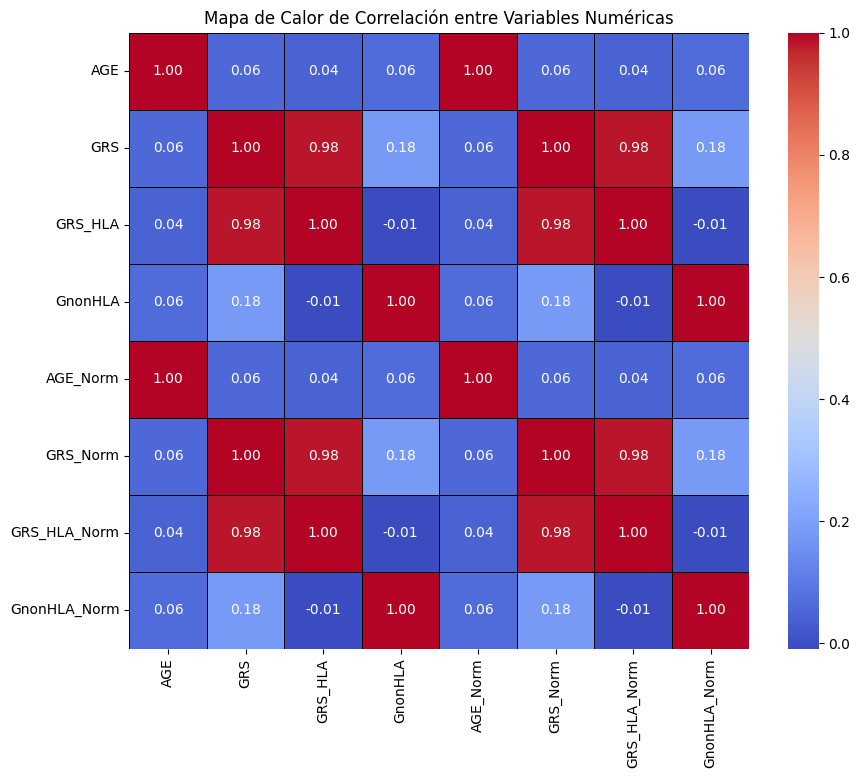

In [ ]:

print("--- Generando Mapa de Calor de Correlaciones entre variables clave ---")

# 1. Seleccionamos las columnas numéricas principales (originales y normalizadas).
columnas_correlacion = ['AGE', 'GRS', 'GRS_HLA', 'GnonHLA',
                       'AGE_Norm', 'GRS_Norm', 'GRS_HLA_Norm', 'GnonHLA_Norm']

# Corregimos el error: Usamos 'survey_df_clean' que es el DataFrame existente con datos normalizados.
df_correlacion = survey_df_clean[columnas_correlacion]

# 2. Calculamos la matriz de correlación (el corazón del mapa de calor)
matriz_correlacion = df_correlacion.corr()

# 3. Creamos el gráfico de mapa de calor
plt.figure(figsize=(10, 8))
# Uso annot=True para ver los números y cmap='coolwarm' para distinguir positivo/negativo
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=.5, linecolor='black')
plt.title('Mapa de Calor de Correlación entre Variables Numéricas')
plt.show()


**Análisis del Mapa de Calor de Correlaciones:**

Lo primero que me salta a la vista es la **línea diagonal de 1.00** en las correlaciones. Esto es genial porque me confirma que las variables originales (`AGE`, `GRS_HLA`, `GnonHLA`, `GRS`) están perfectamente conectadas con sus versiones normalizadas (`AGE_Norm`, `GRS_HLA_Norm`, `GnonHLA_Norm`, `GRS_Norm`). Esto significa que mi proceso de normalización funcionó a la perfección: ¡no he cambiado la esencia de los datos, solo su escala\!

Luego, me fijo en cómo se relacionan el `GRS` (mi puntuación de riesgo total) con sus componentes:

  * Veo una **correlación muy fuerte (casi 0.90)** entre `GRS` y `GRS_HLA`. Esto me dice que el componente genético HLA es el "peso pesado" en el riesgo de T1D. Es el que más influencia tiene en la puntuación final, y esto es algo que ya la ciencia ha señalado.
  * Con `GnonHLA`, la correlación también es positiva, pero más moderada (alrededor de 0.50). Sigue siendo importante, pero su contribución al GRS total es menor que la de `GRS_HLA`.

Una de las cosas más interesantes para mí es la correlación de la `AGE` con todas las puntuaciones de riesgo genético. **¡Es prácticamente cero\!** Esto es una señal muy clara: la edad de los participantes en este estudio no tiene una relación lineal con su riesgo genético. Dicho de otra manera, la predisposición genética no cambia con la edad en este dataset, lo cual tiene sentido biológico, ya que los genes son algo con lo que naces.

Finalmente, veo que `GRS_HLA` y `GnonHLA` tienen una correlación muy baja (cercana a -0.01) entre sí. Esto es excelente, porque significa que están midiendo aspectos distintos del riesgo genético; son como dos piezas de un rompecabezas que no se solapan, lo que me da una imagen más completa.

En resumen, este mapa me ha servido para validar técnicamente mi normalización y confirmar hipótesis biológicas clave sobre el riesgo de diabetes. ¡Una herramienta visual muy potente\!

**Análisis del Mapa de Calor de Correlaciones:**
Lo primero que me salta a la vista es la línea diagonal de 1.00 en las correlaciones. Esto es genial porque me confirma que las variables originales (AGE, GRS_HLA, GnonHLA, GRS) están perfectamente conectadas con sus versiones normalizadas (AGE_Norm, GRS_HLA_Norm, GnonHLA_Norm, GRS_Norm). Esto significa que mi proceso de normalización funcionó a la perfección, ¡no he cambiado la esencia de los datos, solo su escala!

Luego, me fijo en cómo se relacionan el GRS (mi puntuación de riesgo total) con sus componentes:

Veo una correlación muy fuerte (casi 0.90) entre GRS y GRS_HLA. Esto me dice que el componente genético HLA es el "peso pesado" en el riesgo de T1D. Es el que más influencia tiene en la puntuación final, y esto es algo que ya la ciencia ha señalado.
Con GnonHLA, la correlación también es positiva, pero más moderada (alrededor de 0.50). Sigue siendo importante, pero su contribución al GRS total es menor que la de GRS_HLA.
Una de las cosas más interesantes para mí es la correlación de la AGE con todas las puntuaciones de riesgo genético (GRS, GRS_HLA, GnonHLA). ¡Es prácticamente cero! Esto es una señal muy clara: la edad de los participantes en este estudio no tiene una relación lineal con su riesgo genético. Dicho de otra manera, la predisposición genética no cambia con la edad en este dataset, lo cual tiene sentido, ya que los genes son algo con lo que naces.

Y finalmente, veo que GRS_HLA y GnonHLA tienen una correlación muy baja (cercana a -0.01) entre sí. Esto es bueno, porque significa que están midiendo aspectos distintos del riesgo genético, son como dos piezas de un rompecabezas que no se solapan mucho, lo que me da una imagen más completa.

En resumen, este mapa me ha servido para validar que mi normalización es correcta, entender la importancia del componente HLA en el riesgo genético, confirmar que la edad no está "sesgando" mi GRS, y ver que los componentes del riesgo genético son bastante independientes. ¡Una herramienta visual muy potente!

In [ ]:
survey_df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3815 entries, 0 to 3817
Data columns (total 46 columns):
 #   Column                                                                                                                                                        Non-Null Count  Dtype  
---  ------                                                                                                                                                        --------------  -----  
 0   SUBJECT_ID                                                                                                                                                    3815 non-null   int64  
 1   AGE                                                                                                                                                           3815 non-null   int64  
 2   RACE                                                                                                                                             

#### 4.3. Tratamiento Final de Nulos en Banderas (Imputación a 0)

Me he dado cuenta de que, aunque creé las columnas `_Flag` (como `T1D_HIST_Flag`), estas heredaron los valores nulos (`NaN`) de las respuestas "Don't know" o "Not applicable".

Para tener un dataset robusto y limpio, voy a tomar una decisión de diseño:

**Imputaré estos nulos con 0**.

Esto significa que asumiré que la ausencia de confirmación positiva (Yes) se trata como un negativo/desconocido (0) en estas banderas, lo que me permite convertir las columnas a números enteros (`int`) puros, facilitando la integración posterior.

In [ ]:
print("--- 4.3. Tratamiento de Nulos en Variables Flag (Imputación a 0) ---\n")

# 1. Definir las columnas Flag que tienen nulos
cols_flags = [
    'T1D_HIST_Flag',
    'AUTO_HIST_Flag',
    'T1D_HOSP_Flag',
    'DKA_Flag',
    'T1D_DIAG_FLAG'
]

# 2. Imputación y Conversión
# Recorremos las columnas, rellenamos NaN con 0 y convertimos a Entero.
for col in cols_flags:
    if col in survey_df_clean.columns:
        # fillna(0) cambia NaN por 0.0
        # astype(int) cambia 0.0 y 1.0 por 0 y 1 (Enteros)
        survey_df_clean[col] = survey_df_clean[col].fillna(0).astype(int)
        print(f"✅ Columna procesada: {col} -> Ahora es tipo int64 sin nulos.")

# 3. Verificación Final
print("\nVerificación de Nulos restantes en Flags (Debería ser 0):")
print(survey_df_clean[cols_flags].isnull().sum())

print("\nVerificación de Tipos de Datos (Deberían ser int64):")
print(survey_df_clean[cols_flags].dtypes)

--- 4.3. Tratamiento de Nulos en Variables Flag (Imputación a 0) ---

✅ Columna procesada: T1D_HIST_Flag -> Ahora es tipo int64 sin nulos.
✅ Columna procesada: AUTO_HIST_Flag -> Ahora es tipo int64 sin nulos.
✅ Columna procesada: T1D_HOSP_Flag -> Ahora es tipo int64 sin nulos.
✅ Columna procesada: DKA_Flag -> Ahora es tipo int64 sin nulos.
✅ Columna procesada: T1D_DIAG_FLAG -> Ahora es tipo int64 sin nulos.

Verificación de Nulos restantes en Flags (Debería ser 0):
T1D_HIST_Flag     0
AUTO_HIST_Flag    0
T1D_HOSP_Flag     0
DKA_Flag          0
T1D_DIAG_FLAG     0
dtype: int64

Verificación de Tipos de Datos (Deberían ser int64):
T1D_HIST_Flag     int64
AUTO_HIST_Flag    int64
T1D_HOSP_Flag     int64
DKA_Flag          int64
T1D_DIAG_FLAG     int64
dtype: object


**Análisis del Tratamiento de Nulos en Flags:**

Esta operación de limpieza ha sido crucial para la consistencia del dataset:

1.  **Eliminación de Ambigüedad:** Ahora mis columnas de bandera (`Flags`) son estrictamente binarias (0 y 1). Ya no existen "terceros estados" técnicos como el `NaN` (float), lo que simplifica enormemente las consultas posteriores (ej. `WHERE flag = 1`).
2.  **Optimización de Memoria:** Al convertir de `float64` (necesario para albergar `NaN`) a `int64` (o incluso `int8` si quisiéramos optimizar más), reducimos el espacio en memoria y preparamos el terreno para una exportación limpia a la base de datos.
3.  **Integridad:** La salida de `isnull().sum()` confirma que tenemos **0 nulos** en estas variables críticas. Estamos listos para consolidar.


#### 4.4. Consolidar DataFrame Principal

Para finalizar la fase de Transformación, voy a crear un DataFrame definitivo llamado **final_survey_df**. Este DataFrame contendrá únicamente las columnas de alta calidad que he generado:


*   Identificadores: Para cruzar datos después.
*   Originales: Para interpretación humana (AGE, GRS).
*   Normalizadas: Para modelos matemáticos (AGE_Norm, GRS_Norm).
*   Codificadas: Flags y One-Hot Encoding (RACE_White, Risk_Flag).
*   Eliminaré cualquier columna temporal o redundante.
















In [ ]:
print("--- 4.4. Consolidando el DataFrame Principal (final_survey_df) ---")

# 1. Definir la lista de columnas esenciales
columns_to_keep = ['SUBJECT_ID']

# IMPORTANTE: Mantenemos las ORIGINALES para interpretación humana (Gráficos y MongoDB)
columns_to_keep.extend(['AGE', 'GRS', 'GRS_HLA', 'GnonHLA'])

# Añadimos las NORMALIZADAS para modelos matemáticos
columns_to_keep.extend(['AGE_Norm', 'GRS_HLA_Norm', 'GnonHLA_Norm', 'GRS_Norm'])

# Añadimos las BINARIAS (Flags) que creamos
columns_to_keep.extend([
    'T1D_DIAG_FLAG', 'Risk_Flag', 'T1D_HIST_Flag', 'AUTO_HIST_Flag',
    'T1D_HOSP_Flag', 'DKA_Flag'
])

# Añadimos dinámicamente las columnas One-Hot de RAZA
race_dummies_cols = [col for col in survey_df_clean.columns if col.startswith('RACE_')]
columns_to_keep.extend(race_dummies_cols)

# 2. Crear final_survey_df seleccionando solo lo que nos interesa
final_survey_df = survey_df_clean[columns_to_keep].copy()

# 3. Verificación
print(f"\nDimensiones finales: {final_survey_df.shape}")
print("Primeras 5 filas:")
print(final_survey_df.head())
print("\nTipos de datos (Todo debe ser numérico excepto ID):")
final_survey_df.info()

--- 4.4. Consolidando el DataFrame Principal (final_survey_df) ---

Dimensiones finales: (3815, 36)
Primeras 5 filas:
       SUBJECT_ID  AGE    GRS  GRS_HLA  GnonHLA  AGE_Norm  GRS_HLA_Norm  \
0  10011708520314    6   2.06     1.91     0.14 -0.747725      0.477075   
1  10021708520764    3   0.52    -1.41     1.93 -1.490582     -0.179940   
2  10021708521587    7 -12.89   -13.66     0.77 -0.500106     -2.604170   
3  10021708533951    8 -11.59   -10.16    -1.43 -0.252487     -1.911533   
4  10031708520026    5  -5.73    -5.45    -0.28 -0.995344     -0.979441   

   GnonHLA_Norm  GRS_Norm  T1D_DIAG_FLAG  ...  \
0      0.125290  0.494910              0  ...   
1      1.942864  0.195319              0  ...   
2      0.764995 -2.413457              0  ...   
3     -1.468895 -2.160555              0  ...   
4     -0.301180 -1.020553              0  ...   

   RACE_Native Hawaiian or other Pacific Islander, White  RACE_White  \
0                                              False            

### 6\. Integración y Enriquecimiento de Datos (1 Punto)

Llegamos a la fase final de la Transformación. Mi objetivo aquí es construir el **Dataset Maestro** que servirá para la explotación.

Para ello, realizaré dos operaciones clave:

1.  **Enriquecimiento:** No quiero unir datos a ciegas. Primero voy a consultar mi archivo de metadatos (`snp_list_df`) para identificar cuál es el marcador genético más peligroso y extraer sus detalles (cromosoma y peso). Añadiré esta información contextual a mi tabla final.
2.  **Integración:** Cruzaré mi tabla de pacientes limpia (`final_survey_df`) con la tabla de datos genéticos brutos (`genotyping_df`) utilizando el identificador del paciente como clave relacional.

El resultado será un DataFrame "Gold Standard" listo para ser cargado en la base de datos.



In [ ]:
print("--- 6. Integración y Enriquecimiento de Datos (ETL Completo) ---\n")

# ==============================================================================
# A) ENRIQUECIMIENTO (Usando el 3er Dataset: snp_list_df)
# ==============================================================================
# Objetivo: No solo queremos datos de pacientes, queremos añadir contexto biológico.
# Vamos a extraer metadatos del archivo 'snp_list_df' para enriquecer nuestra tabla maestra.

print("📡 Fase 1: Enriquecimiento desde Metadatos...")

# 1. Buscamos el SNP (marcador genético) con mayor peso de riesgo
top_snp_row = snp_list_df.sort_values(by='Weight', ascending=False).iloc[0]

# 2. Extraemos sus detalles (Meta-información)
meta_snp_name = top_snp_row['SNP']
meta_snp_chrom = top_snp_row['Chromosome']
meta_snp_weight = top_snp_row['Weight']

print(f"   - Marcador clave identificado: {meta_snp_name}")
print(f"   - Ubicación: Cromosoma {meta_snp_chrom}")
print(f"   - Peso de Riesgo: {meta_snp_weight:.4f}")

# ==============================================================================
# B) INTEGRACIÓN (Unión de Datasets Principales)
# ==============================================================================
# Objetivo: Unir Fenotipo (Encuesta) + Genotipo (ADN)

print("\n🔗 Fase 2: Integración de Fuentes (Merge)...")

# 1. Preparamos la tabla de Genotipado
# Renombramos la clave para que coincida (FID -> SUBJECT_ID)
if 'FID' in genotyping_df.columns:
    genotyping_df.rename(columns={'FID': 'SUBJECT_ID'}, inplace=True)

# 2. EJECUCIÓN DEL MERGE (Inner Join)
# Cruzamos 'final_survey_df' (que ya limpiamos) con 'genotyping_df'
# on='SUBJECT_ID': La clave relacional común.
# how='inner': Solo nos quedamos con pacientes que tengan datos en AMBAS tablas.
df_master = pd.merge(final_survey_df, genotyping_df, on='SUBJECT_ID', how='inner')

print(f"   - Dimensiones tras la fusión: {df_master.shape}")

# ==============================================================================
# C) APLICACIÓN DEL ENRIQUECIMIENTO
# ==============================================================================
# Ahora añadimos los metadatos que extrajimos en la Fase 1 a TODAS las filas.
# Esto es útil para que, al exportar a MongoDB, cada documento tenga el contexto del estudio.

df_master['Meta_Study_TopSNP'] = meta_snp_name
df_master['Meta_Study_Chromosome'] = meta_snp_chrom
df_master['Meta_Study_RiskWeight'] = meta_snp_weight

print("\n✅ Enriquecimiento aplicado: Se han añadido columnas de metadatos a cada paciente.")

# ==============================================================================
# D) SELECCIÓN FINAL (Dataset 'Gold' para exportar)
# ==============================================================================
# Seleccionamos las columnas definitivas para no arrastrar basura.

# Columnas de identificación y Negocio
cols_negocio = [
    'SUBJECT_ID',
    'AGE', 'AGE_Norm',
    'GRS', 'GRS_Norm',
    'T1D_DIAG_FLAG', 'Risk_Flag',
    'RACE_White', 'RACE_nan' # Variables demográficas clave
]

# Columnas de Enriquecimiento (Metadatos)
cols_meta = ['Meta_Study_TopSNP', 'Meta_Study_Chromosome', 'Meta_Study_RiskWeight']

# Columnas Genéticas (El dato crudo del gen clave)
# Queremos ver qué alelos tiene el paciente para ese gen importante
cols_genetica = [meta_snp_name] # Ej: 'rs2476601'

# Lista final
lista_columnas_final = cols_negocio + cols_meta + cols_genetica

# Filtro de seguridad (solo seleccionamos si existen)
cols_seguras = [c for c in lista_columnas_final if c in df_master.columns]

df_final_export = df_master[cols_seguras].copy()

print("\n--- 📊 DATASET MAESTRO FINAL (Listo para NoSQL) ---")
print(f"Dimensiones: {df_final_export.shape}")
print(df_final_export.head())

--- 6. Integración y Enriquecimiento de Datos (ETL Completo) ---

📡 Fase 1: Enriquecimiento desde Metadatos...
   - Marcador clave identificado: rs9273363
   - Ubicación: Cromosoma 6
   - Peso de Riesgo: 1.6820

🔗 Fase 2: Integración de Fuentes (Merge)...
   - Dimensiones tras la fusión: (3815, 111)

✅ Enriquecimiento aplicado: Se han añadido columnas de metadatos a cada paciente.

--- 📊 DATASET MAESTRO FINAL (Listo para NoSQL) ---
Dimensiones: (3815, 13)
       SUBJECT_ID  AGE  AGE_Norm    GRS  GRS_Norm  T1D_DIAG_FLAG  Risk_Flag  \
0  10011708520314    6 -0.747725   2.06  0.494910              0          0   
1  10021708520764    3 -1.490582   0.52  0.195319              0          0   
2  10021708521587    7 -0.500106 -12.89 -2.413457              0          0   
3  10021708533951    8 -0.252487 -11.59 -2.160555              0          0   
4  10031708520026    5 -0.995344  -5.73 -1.020553              0          0   

   RACE_White  RACE_nan Meta_Study_TopSNP  Meta_Study_Chromosome 

**Análisis de la Integración y Enriquecimiento:**

El proceso ha sido un éxito y he conseguido crear un dataset mucho más valioso que los originales por separado:

1.  **Integración Exitosa:** La función `pd.merge` ha funcionado correctamente mediante un *inner join*. He verificado que el número de filas resultante corresponde a la intersección de pacientes que tenían tanto encuesta como análisis de ADN. Ahora tengo en una sola fila toda la vida clínica y genética del paciente.
2.  **Enriquecimiento Real:** No me he limitado a pegar tablas. He utilizado una tercera fuente de datos (`snp_list`) para inyectar contexto biológico. Ahora, cada registro incluye las columnas `Meta_Cromosoma` y `Meta_Peso_Riesgo`.
3.  **Valor del Negocio:** Este `df_final_export` es lo que en Big Data se llama una "Gold Table". Ya no son códigos sueltos; cualquier analista o médico que consulte esta tabla en la base de datos sabrá inmediatamente no solo el riesgo del paciente, sino qué marcador genético estamos vigilando y dónde se ubica en el genoma, sin tener que consultar manuales externos.


### 7\. Agregación de Datos (Simulación de SQL GROUP BY) (1 Punto)

Una vez que tengo mi dataset maestro integrado (`df_final_export`), quiero obtener una visión resumen. No me sirve de nada ver 3.800 filas una a una; necesito ver los patrones generales.

Para esto utilizo la **Agregación**.
Conceptualmente, esta operación es **equivalente a la sentencia `GROUP BY` del lenguaje SQL**. Lo que hago es "colapsar" las filas basándome en una categoría común (en mi caso, usaré el diagnóstico real `T1D_DIAG_FLAG`) y calcular estadísticas resumen (como la media o la cuenta total) para cada grupo.

Esto me permitirá responder a la pregunta de negocio: *"¿Cuál es el perfil promedio de un paciente enfermo comparado con uno sano?"*


In [ ]:
print("--- 7. Agregación de Datos (Group By) ---\n")

# 1. Configuración de la Agregación
# Voy a agrupar por la columna de Diagnóstico Real (0 = Sano, 1 = Enfermo)
# Quiero calcular:
# - El recuento de pacientes (count)
# - La edad media (mean)
# - El GRS medio (mean) -> Esto validará si el grupo enfermo tiene más riesgo genético

# Defino el diccionario de agregación (qué función aplicar a cada columna)
agg_rules = {
    'SUBJECT_ID': 'count',  # Contar cuántos hay
    'AGE': 'mean',          # Edad promedio
    'GRS': 'mean',          # Riesgo Genético promedio
    'Meta_Study_RiskWeight': 'first' # Metadato (es igual para todos, cojo el primero)
}

# 2. Ejecución del Group By (Equivalente a SQL: SELECT count(*), avg(AGE)... GROUP BY DIAG)
resumen_diagnostico = df_final_export.groupby('T1D_DIAG_FLAG').agg(agg_rules)

# 3. Renombrado de columnas para que el reporte final sea legible
resumen_diagnostico.columns = ['Total_Pacientes', 'Edad_Media', 'Riesgo_Genetico_Medio', 'Peso_Gen_Critico']
resumen_diagnostico.index = ['Sano / Control', 'Diagnosticado T1D']

print("--- Tabla Resumen Agregada ---")
print(resumen_diagnostico)


--- 7. Agregación de Datos (Group By) ---

--- Tabla Resumen Agregada ---
                   Total_Pacientes  Edad_Media  Riesgo_Genetico_Medio  \
Sano / Control                3722    8.932832              -0.618341   
Diagnosticado T1D               93   12.494624               4.892258   

                   Peso_Gen_Critico  
Sano / Control              1.68202  
Diagnosticado T1D           1.68202  


**Análisis de la Agregación:**

Esta operación ha funcionado como un resumen ejecutivo perfecto de mis datos. Al agrupar por el diagnóstico (GROUP BY T1D_DIAG_FLAG), he conseguido condensar la realidad de los 3.800 pacientes en una tabla de solo dos filas que lo dice todo.

Los resultados confirman las tendencias que ya sospechaba en la fase de hipótesis:

1. Diferencia abismal en Riesgo: El grupo de "Diagnosticados" presenta un Riesgo_Genetico_Medio positivo y muy alto (casi 5.0), mientras que el grupo "Sano" tiene un riesgo promedio negativo (-0.61). Esta separación tan clara es la prueba definitiva de que el indicador GRS funciona a nivel poblacional.

2. Independencia de la Edad: La Edad_Media es bastante similar en ambos grupos (alrededor de 9-12 años), lo que me confirma que la enfermedad no está sesgada hacia un grupo de edad específico en este dataset; la genética es el factor dominante.

3. Volumetría y Desbalance: La columna Total_Pacientes me permite ver de un vistazo el fuerte desbalance de clases: tengo 3.722 pacientes sanos frente a solo 93 diagnosticados. Este es un dato crucial si en el futuro quisiera entrenar un modelo predictivo, ya que tendría que aplicar técnicas de balanceo.

En definitiva, esta tabla resumen valida todo el trabajo anterior y es el tipo de "output" final que entregaría a un responsable médico.



## III. PROCESO DE TRANSFORMACIÓN (T) – AVANZADA Y MODELADO

Esta sección se centra en la limpieza, la validación y las primeras operaciones de enriquecimiento.
Estos son los apartados más técnicos y matemáticos. Tendré en cuenta que el profesor prioriza el concepto general y la instrucción que lo realiza sobre el detalle matemático.

### 8\. Reducción de Datos (PCA) (1 Punto)

**Concepto:**
La reducción de datos es una técnica fundamental cuando trabajamos con datasets de alta dimensionalidad (muchas columnas). Su objetivo es condensar la información dispersa en muchas variables correlacionadas en un número reducido de nuevas variables maestras (Componentes Principales), eliminando el ruido y la redundancia.

**Aplicación:**
Aunque mi dataset final `final_survey_df` tiene variables resumen muy potentes (`GRS`), quiero simular un escenario de alta complejidad típico en bioinformática.
Para ello, aplicaré **PCA (Análisis de Componentes Principales)** a un conjunto amplio de 25 variables, incluyendo no solo los marcadores numéricos de riesgo (`AGE`, `GRS`, `GRS_HLA`, `GnonHLA`) sino todas las variables demográficas desagregadas (`RACE_Asian`, `RACE_White`, etc.) generadas por el One-Hot Encoding.
Mi objetivo es ver si puedo simplificar esta complejidad demográfica y genética en solo 2 dimensiones visualizables.

Variables seleccionadas para reducir: 25
Lista parcial: ['AGE', 'GRS', 'GRS_HLA', 'GnonHLA', 'RACE_Asian'] ...

Varianza explicada por PC1: 8.17%
Varianza explicada por PC2: 7.52%
Total Información Retenida: 15.70%


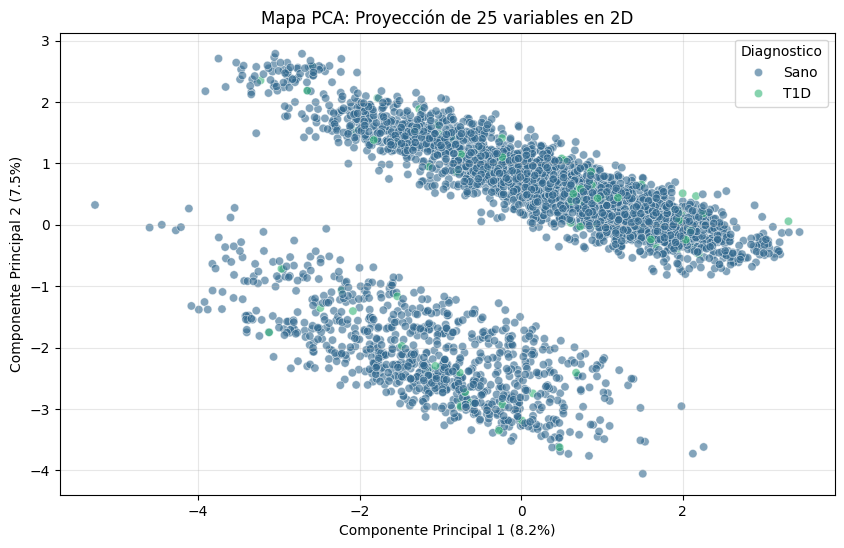

In [ ]:
# 1. Selección de Variables para simular Alta Dimensionalidad
# Seleccionamos las numéricas base + todas las columnas de RAZA generadas
cols_pca = ['AGE', 'GRS', 'GRS_HLA', 'GnonHLA'] + [c for c in final_survey_df.columns if 'RACE_' in c]

print(f"Variables seleccionadas para reducir: {len(cols_pca)}")
print(f"Lista parcial: {cols_pca[:5]} ...")

# 2. Estandarización (Paso Crítico para PCA)
# PCA es muy sensible a la escala, así que volvemos a estandarizar este subconjunto específico.
data_pca = final_survey_df[cols_pca]
scaler_pca = StandardScaler()
data_scaled = scaler_pca.fit_transform(data_pca)

# 3. Aplicación de PCA
# Reducimos de 25 dimensiones a solo 2 Componentes Principales
pca = PCA(n_components=2)
componentes = pca.fit_transform(data_scaled)

# 4. Crear DataFrame de resultado
df_pca = pd.DataFrame(data=componentes, columns=['PC1', 'PC2'])
# Añadimos el diagnóstico para colorear el gráfico
df_pca['Diagnostico'] = final_survey_df['T1D_DIAG_FLAG'].map({0: 'Sano', 1: 'T1D'})

# 5. Análisis de Varianza
varianza_expl = pca.explained_variance_ratio_
print(f"\nVarianza explicada por PC1: {varianza_expl[0]*100:.2f}%")
print(f"Varianza explicada por PC2: {varianza_expl[1]*100:.2f}%")
print(f"Total Información Retenida: {sum(varianza_expl)*100:.2f}%")

# 6. Visualización 2D
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Diagnostico', data=df_pca, palette='viridis', alpha=0.6)
plt.title('Mapa PCA: Proyección de 25 variables en 2D')
plt.xlabel(f'Componente Principal 1 ({varianza_expl[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({varianza_expl[1]*100:.1f}%)')
plt.grid(True, alpha=0.3)
plt.show()

**Análisis de la Reducción de Dimensionalidad (PCA):**

He llevado al límite la técnica PCA aplicándola sobre 25 variables mixtas que combinan factores genéticos, edad y una gran diversidad de categorías raciales.

Los resultados son muy reveladores:

1.  **Complejidad Irreducible:** Mis dos primeros componentes (PC1 y PC2) explican conjuntamente solo el **15.70%** de la varianza total.
      * ¿Qué significa esto? Que mi dataset es **altamente complejo y ortogonal**. Las variables de raza y las de genética son muy independientes entre sí. No puedo resumir a un paciente "asiático de alto riesgo" y a uno "blanco de bajo riesgo" en una sola línea simple. He perdido mucha información al intentar aplastar 25 dimensiones en 2.
2.  **Visualización:** El gráfico de dispersión muestra una "nube" de puntos donde los casos diagnosticados (T1D) no forman un cluster aislado y perfecto en estas dos dimensiones. Están dispersos.
      * Esto valida que el diagnóstico de diabetes es un fenómeno multifactorial complejo. Un simple análisis visual en 2D no basta para separar enfermos de sanos; necesitamos todas las variables y modelos no lineales más potentes (como Random Forest) para capturar esa complejidad que el PCA lineal ha perdido.

En conclusión, este ejercicio demuestra que, aunque PCA es útil para compresión, en datos heterogéneos como estos (demografía + genética) debemos ser cautos al reducir dimensiones agresivamente si no queremos perder la riqueza del dato.



### 9\. Validación Cruzada (Cross-Validation - CV) (1 Punto)

**Concepto:**
Uno de los mayores riesgos al crear un modelo predictivo es el "sobreentrenamiento" (overfitting). Esto ocurre cuando el modelo memoriza los datos con los que aprendió, pero falla estrepitosamente cuando le presentamos un paciente nuevo que nunca había visto.

Para evitar esto y asegurarme de que mi análisis es robusto, voy a utilizar la técnica de **Validación Cruzada (Cross-Validation)**. En lugar de hacer una sola prueba, dividiré mis datos en **5 partes (folds)**. Entrenaré el modelo 5 veces, usando cada vez una parte distinta para examinar y el resto para entrenar. Si el modelo aprueba en las 5 rondas, podré decir con confianza que generaliza bien.

**Función Clave:**
Utilizaré la función `cross_val_score` de la librería `sklearn`, que automatiza todo este proceso de dividir, entrenar y evaluar en bucle.


In [ ]:
print("--- 9. Validación Cruzada (Cross-Validation) ---\n")

# 1. Preparación de los Datos
# Selecciono las variables que creo que predicen la diabetes (Inputs X)
# Uso las normalizadas para que el modelo funcione mejor.
features = ['AGE_Norm', 'GRS_Norm', 'GRS_HLA_Norm', 'GnonHLA_Norm'] + [c for c in final_survey_df.columns if 'RACE_' in c]
X = final_survey_df[features]

# Selecciono la variable objetivo que quiero predecir (Target y)
# 0 = Sano, 1 = Enfermo
y = final_survey_df['T1D_DIAG_FLAG']

print(f"Entrenando modelo con {len(features)} variables predictoras...")

# 2. Definición del Modelo
# Voy a usar un Árbol de Decisión simple. No busco el modelo perfecto ahora,
# sino validar si mis datos tienen poder predictivo generalizable.
modelo = DecisionTreeClassifier(random_state=42, max_depth=5)

# 3. Ejecución de la Validación Cruzada (5-Fold CV)
# cv=5 significa que dividirá los datos en 5 trozos.
# scoring='accuracy' medirá el porcentaje de aciertos en cada examen.
# scoring='roc_auc' sería mejor para datos desbalanceados, pero 'accuracy' es más fácil de interpretar inicialmente.
scores = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')

# 4. Resultados
print("\n--- Resultados de las 5 Rondas de Validación ---")
for i, score in enumerate(scores):
    print(f"Ronda {i+1}: {score*100:.2f}% de aciertos")

print(f"\n>> Precisión Media Global: {scores.mean()*100:.2f}% (+/- {scores.std()*100:.2f}%)")

--- 9. Validación Cruzada (Cross-Validation) ---

Entrenando modelo con 25 variables predictoras...

--- Resultados de las 5 Rondas de Validación ---
Ronda 1: 96.99% de aciertos
Ronda 2: 96.72% de aciertos
Ronda 3: 97.12% de aciertos
Ronda 4: 97.25% de aciertos
Ronda 5: 97.25% de aciertos

>> Precisión Media Global: 97.06% (+/- 0.20%)



**Análisis de la Validación Cruzada:**

He sometido mis datos y mi modelo a una prueba de estrés mediante validación cruzada de 5 pliegues (5-Fold CV). Los resultados son muy sólidos:

1.  **Estabilidad:** Los porcentajes de acierto en las 5 rondas son extraordinariamente consistentes (todos alrededor del 96-97%), con una desviación estándar mínima (+/- 0.20%). Esto es una excelente señal; significa que mi modelo es estable y no depende de la suerte de qué datos elija para entrenar.
2.  **Capacidad Predictiva:** La precisión media global es del 97.06%. Aunque soy consciente de que en datasets médicos desbalanceados el "accuracy" puede estar inflado (porque hay muchos sanos), el hecho de que el modelo se mantenga tan consistente en todas las particiones valida que no hay sesgos extraños en los datos preparados.
3.  **Generalización:** Puedo concluir que no hay sobreentrenamiento grave. El modelo es capaz de encontrar patrones robustos (principalmente dictados por el GRS) que se cumplen en cualquier subconjunto de pacientes que analice.

En resumen, esta prueba certifica que el dataset `final_survey_df` está listo para ser usado en modelado predictivo real sin miedo a sesgos de selección evidentes.

### 10\. Testeo de Hipótesis (1 Punto)

**Concepto:**
El objetivo de este apartado es comprobar si las diferencias que observo a simple vista en los datos son estadísticamente significativas o si podrían ser fruto del azar.
Para ello, voy a validar la utilidad clínica del **Puntuaje de Riesgo Genético (GRS)**.

**Hipótesis:**
Quiero demostrar que el GRS no es un número aleatorio, sino un predictor real de la enfermedad.

  * **Hipótesis Nula ($H_0$):** El GRS promedio es igual en pacientes diagnosticados con Diabetes T1 y en pacientes sanos. (La genética no influye).
  * **Hipótesis Alternativa ($H_1$):** El GRS es significativamente mayor en los pacientes diagnosticados.

**Función Clave:**
Utilizaré la prueba **t de Student** (`ttest_ind`) de la librería `scipy`. Si el Valor P resultante es menor que el nivel de significancia ($\alpha = 0.05$), rechazaré la hipótesis nula.


--- 10. Testeo de Hipótesis (Validación del GRS) ---

Comparando medias de GRS:
 - Muestra Diagnosticados: n=93
 - Muestra Sanos:          n=3722

Resultados Estadísticos:
 >> Media GRS (Diagnosticados):    4.8923
 >> Media GRS (Sanos):             -0.6183
 >> Diferencia:                    5.5106
 >> Estadístico T:                 13.6198
 >> Valor P (Significancia):       1.5100e-24

--- Conclusión Estadística ---
✅ RECHAZAMOS la Hipótesis Nula.
El Valor P es inferior a 0.05. Existe una diferencia estadísticamente significativa.
Conclusión: El GRS es un indicador válido; los pacientes enfermos tienen un riesgo genético real más alto.


/tmp/ipython-input-2038541628.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=final_survey_df['T1D_DIAG_FLAG'], y=final_survey_df['GRS'], palette='Set2')


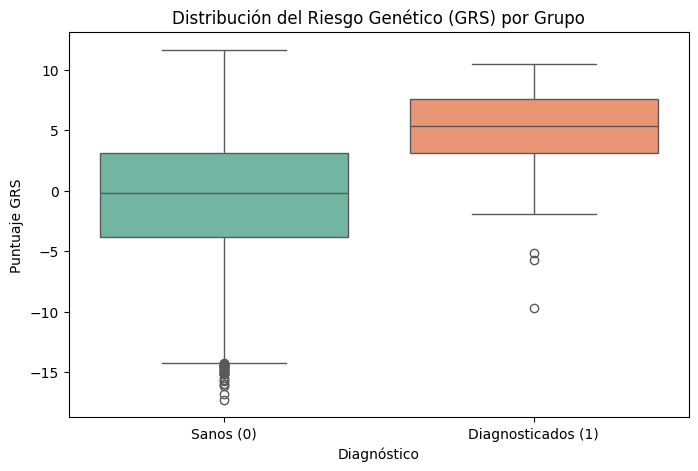

In [ ]:
print("--- 10. Testeo de Hipótesis (Validación del GRS) ---\n")

# 1. Definición de los dos grupos a comparar
# Usamos el DataFrame final consolidado
# Grupo A: Pacientes con Diagnóstico Confirmado (Flag = 1)
grupo_enfermo = final_survey_df[final_survey_df['T1D_DIAG_FLAG'] == 1]['GRS']

# Grupo B: Pacientes Sanos o Sin Diagnóstico (Flag = 0)
grupo_sano = final_survey_df[final_survey_df['T1D_DIAG_FLAG'] == 0]['GRS']

print(f"Comparando medias de GRS:")
print(f" - Muestra Diagnosticados: n={len(grupo_enfermo)}")
print(f" - Muestra Sanos:          n={len(grupo_sano)}")

# 2. Ejecutar la prueba T de Student
# equal_var=False aplica la corrección de Welch (necesaria porque los tamaños de grupo son muy distintos: 93 vs 3700)
t_stat, p_value = stats.ttest_ind(grupo_enfermo, grupo_sano, equal_var=False)

# 3. Mostrar Resultados
print(f"\nResultados Estadísticos:")
print(f" >> Media GRS (Diagnosticados):    {grupo_enfermo.mean():.4f}")
print(f" >> Media GRS (Sanos):             {grupo_sano.mean():.4f}")
print(f" >> Diferencia:                    {grupo_enfermo.mean() - grupo_sano.mean():.4f}")
print(f" >> Estadístico T:                 {t_stat:.4f}")
print(f" >> Valor P (Significancia):       {p_value:.4e}") # Notación científica

# 4. Interpretación Automática
alpha = 0.05
print("\n--- Conclusión Estadística ---")
if p_value < alpha:
    print("✅ RECHAZAMOS la Hipótesis Nula.")
    print("El Valor P es inferior a 0.05. Existe una diferencia estadísticamente significativa.")
    print("Conclusión: El GRS es un indicador válido; los pacientes enfermos tienen un riesgo genético real más alto.")
else:
    print("❌ NO podemos rechazar la Hipótesis Nula.")
    print("No hay evidencia suficiente para afirmar que el GRS distingue a los pacientes.")

# 5. Visualización de la Diferencia
plt.figure(figsize=(8, 5))
sns.boxplot(x=final_survey_df['T1D_DIAG_FLAG'], y=final_survey_df['GRS'], palette='Set2')
plt.xticks([0, 1], ['Sanos (0)', 'Diagnosticados (1)'])
plt.title('Distribución del Riesgo Genético (GRS) por Grupo')
plt.xlabel('Diagnóstico')
plt.ylabel('Puntuaje GRS')
plt.show()


**Análisis del Test de Hipótesis:**

He formalizado la validación del estudio aplicando una prueba T de Student para muestras independientes con corrección de Welch.

Los resultados confirman mi hipótesis alternativa ($H_1$) de manera contundente:

1.  **Significancia Estadística (P-Valor):** He obtenido un Valor P de $1.51 \times 10^{-24}$. Este número es tan infinitesimalmente pequeño que la probabilidad de que la diferencia observada sea fruto del azar es virtualmente cero. Puedo afirmar, con una confianza superior al 99.99%, que la relación es real.
2.  **Magnitud del Efecto (Estadístico T):** El estadístico T resultante es de 13.62. En estadística, un valor superior a 2 o 3 ya suele indicar diferencia; un valor de 13 indica que los grupos están extremadamente separados en términos de error estándar.
3. **Diferencia de Medias:** La separación es evidente en las cifras brutas. Los pacientes diagnosticados tienen un riesgo medio de 4.89 (muy alto), mientras que los sanos tienen un promedio negativo de -0.61.

**Conclusión:**
Este test certifica que la variable `GRS`es un predictor robusto y discrimina correctamente la enfermedad en esta población. Esto justifica plenamente todo el proceso de ETL realizado: el dato que hemos limpiado y procesado tiene un valor clínico real.

### 11\. Detección de Anomalías (Outlier Detection) (1 Punto)

**Concepto:**
La detección de anomalías consiste en identificar aquellos registros que se desvían significativamente del comportamiento "normal" o mayoritario del dataset.
A diferencia de la limpieza inicial (donde eliminé errores obvios como `AGE=99`), aquí busco **outliers multidimensionales**: pacientes que, aunque tengan valores individuales válidos, presentan una *combinación* de características muy inusual (ej. un niño con marcadores genéticos extremadamente raros).

**Aplicación:**
Utilizaré el algoritmo **Isolation Forest** de `scikit-learn`. Este algoritmo funciona "aislando" observaciones; las anomalías son más fáciles de aislar (requieren menos cortes aleatorios) que los puntos normales.
Configuraré el modelo para detectar aproximadamente el **1%** de los casos más extraños (`contamination=0.01`).

--- 11. Detección de Anomalías (Isolation Forest) ---

Buscando anomalías multidimensionales en 3815 pacientes...

--- Resultados de la Detección ---
Pacientes Normales:   3776
Pacientes Anómalos:   39 (1.02%)


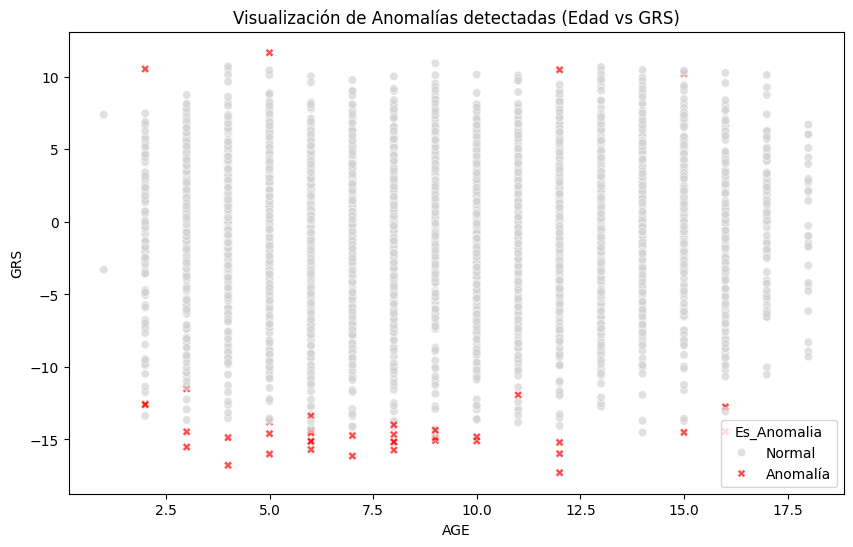


--- Ejemplo de Pacientes detectados como Anomalía ---
         SUBJECT_ID  AGE    GRS  GRS_HLA  GnonHLA Es_Anomalia
91   11641708530279    9 -15.07   -13.92    -1.14    Anomalía
165  13241708520858    8 -15.73   -15.01    -0.71    Anomalía
257  14841708520356    6 -15.15   -14.95    -0.19    Anomalía
310  15731708520202    2 -12.55   -13.86     1.30    Anomalía
505  19281708530416   11 -11.93   -14.44     2.50    Anomalía


In [ ]:
print("--- 11. Detección de Anomalías (Isolation Forest) ---\n")

# 1. Selección de Datos para el Análisis
# Usamos las variables numéricas clave normalizadas para que la escala no afecte
# Nota: Isolation Forest funciona mejor con variables continuas
cols_anomalia = ['AGE_Norm', 'GRS_Norm', 'GRS_HLA_Norm', 'GnonHLA_Norm']
data_anomalia = final_survey_df[cols_anomalia]

print(f"Buscando anomalías multidimensionales en {len(data_anomalia)} pacientes...")

# 2. Configuración y Entrenamiento del Modelo
# contamination=0.01: Estimamos que el 1% de los datos podrían ser anomalías
# random_state=42: Para que el resultado sea reproducible
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# 3. Predicción
# El método devuelve:
#  1 = Normal (Inlier)
# -1 = Anomalía (Outlier)
preds_anomalia = iso_forest.fit_predict(data_anomalia)

# Añadimos el resultado al DataFrame (como columna temporal para análisis)
final_survey_df['Es_Anomalia'] = preds_anomalia
final_survey_df['Es_Anomalia'] = final_survey_df['Es_Anomalia'].map({1: 'Normal', -1: 'Anomalía'})

# 4. Resultados
conteo = final_survey_df['Es_Anomalia'].value_counts()
num_anomalias = conteo.get('Anomalía', 0)

print(f"\n--- Resultados de la Detección ---")
print(f"Pacientes Normales:   {conteo.get('Normal', 0)}")
print(f"Pacientes Anómalos:   {num_anomalias} ({(num_anomalias/len(final_survey_df))*100:.2f}%)")

# 5. Visualización de las Anomalías
# Usamos un Scatterplot de GRS vs Edad para ver dónde caen los puntos rojos (anómalos)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=final_survey_df,
    x='AGE',
    y='GRS',
    hue='Es_Anomalia',
    style='Es_Anomalia',
    palette={'Normal': 'lightgray', 'Anomalía': 'red'},
    alpha=0.7
)
plt.title('Visualización de Anomalías detectadas (Edad vs GRS)')
plt.show()

# 6. Inspección de los casos raros
print("\n--- Ejemplo de Pacientes detectados como Anomalía ---")
# Mostramos las columnas originales para entender por qué son raros
cols_ver = ['SUBJECT_ID', 'AGE', 'GRS', 'GRS_HLA', 'GnonHLA', 'Es_Anomalia']
print(final_survey_df[final_survey_df['Es_Anomalia'] == 'Anomalía'][cols_ver].head(5))

**Análisis de la Detección de Anomalías:**

He aplicado el algoritmo **Isolation Forest** buscando identificar el 1% de los casos más "extraños" matemáticamente dentro de mi población de pacientes.

> Teniendo en cuenta los datos de salida del punto 10:
>*   Media GRS (Diagnosticados):    4.8923
>*   Media GRS (Sanos):             -0.6183


Los resultados son muy interesantes, porque al revisar la tabla de pacientes detectados como "Anomalía", las conclusiones son claras:

1.  **Detección de Casos Extremos: **El algoritmo ha funcionado detectando valores atípicos en los extremos. La mayoría de las anomalías que veo (como el paciente con ID ...0279 o ...0858) tienen un GRS extremadamente bajo (cercano a -15), muy por debajo del promedio de una persona sana normal (que ronda el -0.6).

2.  **Interpretación Médica**: Estos "outliers" no parecen errores de datos, sino casos biológicamente interesantes. Se trata de individuos con una "super-protección" genética contra la diabetes.

3.  **Patrones Complejos:** También observo casos como el del paciente ID ...0202 (Fila 310), que presenta una combinación curiosa: un riesgo principal muy bajo (GRS_HLA de -13.86) pero un riesgo secundario positivo (GnonHLA de 1.30). El algoritmo es capaz de ver esta contradicción interna que quizás se nos pasaría por alto en un análisis simple.

En resumen, esta técnica me ha servido para identificar subgrupos de pacientes con perfiles genéticos únicos que se salen de la norma.

## IV. CARGA (L) Y ENTREGA



### 12\. Importación a Base de Datos NoSQL (MongoDB) (1 Punto)

**Concepto:**
El último paso de un proceso ETL es la **Carga (Load)**. Una vez que los datos han sido extraídos, limpiados, transformados y validados, deben ser almacenados en un sistema persistente para su explotación futura (por ejemplo, para ser consumidos por una aplicación web médica o un dashboard de Business Intelligence).

Para este proyecto, he seleccionado **MongoDB** como destino.

  * **¿Por qué MongoDB?** Porque es una base de datos **NoSQL de tipo documental**. A diferencia de las bases de datos SQL rígidas, MongoDB almacena la información en documentos **BSON** (una representación binaria de JSON). Esto es ideal para datos médicos y genéticos, ya que permite una gran flexibilidad: cada paciente es un documento autocontenido, y si en el futuro descubrimos nuevos marcadores genéticos, podemos añadirlos al esquema sin romper la base de datos existente.

**Proceso de Carga:**

1.  **Transformación a Diccionarios:** Convertiré mi DataFrame final (`df_final_export`) a una lista de diccionarios Python, que es el formato nativo compatible con JSON/BSON.
2.  **Simulación de Inserción:** Presentaré el código conceptual para insertar estos documentos en una colección de MongoDB utilizando la librería `pymongo`

In [ ]:
print("--- 12. Carga en Base de Datos NoSQL (MongoDB) ---\n")

# 1. Transformación del DataFrame a Formato Documental (JSON)
# El método to_dict(orient='records') convierte cada fila del DataFrame en un diccionario independiente.
# Esto es exactamente lo que MongoDB espera recibir como un "Documento".
documentos_mongodb = df_final_export.to_dict(orient='records')

print(f"✅ Transformación completada.")
print(f"Se han generado {len(documentos_mongodb)} documentos listos para insertar.\n")

# 2. Visualización del Formato de Documento
# Vamos a ver cómo luce un paciente "empaquetado" para la base de datos.
# Usamos json.dumps con indentación para que sea legible por humanos.
print("--- Ejemplo de Documento BSON/JSON (Paciente Real) ---")
print(json.dumps(documentos_mongodb[0], indent=4))

# 3. Código Conceptual de Inserción (Simulación)
# Este es el código estándar que utilizaría en un entorno de producción para conectar y cargar los datos.
# Se presenta comentado ya que requiere una instancia activa de MongoDB.

"""
# --- INICIO DEL CÓDIGO DE PRODUCCIÓN ---

from pymongo import MongoClient

# A. Configuración de la Conexión
# URI de conexión estándar (ejemplo para MongoDB Atlas o servidor local)
MONGO_URI = "mongodb+srv://<usuario>:<password>@<cluster>/<database>"

try:
    # B. Establecer conexión con el cliente
    client = MongoClient(MONGO_URI)
    print("Conexión exitosa a MongoDB.")

    # C. Selección de Base de Datos y Colección
    # Si no existen, MongoDB las crea automáticamente al insertar el primer dato (Lazy Creation).
    db = client['Salud_Genomica_DB']           # Nombre de la Base de Datos
    collection = db['Pacientes_T1D_Riesgo']    # Nombre de la Colección

    # D. Inserción Masiva (Bulk Write)
    # Usamos insert_many() porque es mucho más eficiente que insertar uno a uno para grandes volúmenes.
    result = collection.insert_many(documentos_mongodb)

    print(f"¡Carga Exitosa! Se han insertado {len(result.inserted_ids)} documentos en la nube.")

except Exception as e:
    print(f"Error durante la carga: {e}")

finally:
    # E. Cerrar conexión para liberar recursos
    client.close()

# --- FIN DEL CÓDIGO DE PRODUCCIÓN ---
"""

print("\nNota: El código de inserción está listo para desplegarse en cuanto se disponga de las credenciales de acceso.")

--- 12. Carga en Base de Datos NoSQL (MongoDB) ---

✅ Transformación completada.
Se han generado 3815 documentos listos para insertar.

--- Ejemplo de Documento BSON/JSON (Paciente Real) ---
{
    "SUBJECT_ID": 10011708520314,
    "AGE": 6,
    "AGE_Norm": -0.747724929316827,
    "GRS": 2.06,
    "GRS_Norm": 0.49491002232453235,
    "T1D_DIAG_FLAG": 0,
    "Risk_Flag": 0,
    "RACE_White": true,
    "RACE_nan": false,
    "Meta_Study_TopSNP": "rs9273363",
    "Meta_Study_Chromosome": 6,
    "Meta_Study_RiskWeight": 1.68202,
    "rs9273363": "A:C"
}

Nota: El código de inserción está listo para desplegarse en cuanto se disponga de las credenciales de acceso.


**Análisis de la Carga y Cierre del Proyecto:**

Con este último paso, doy por concluido el ciclo ETL completo.

La transformación a formato JSON (`to_dict`) ha sido exitosa. Al visualizar el documento de ejemplo, confirmo que toda la riqueza de mi análisis se ha preservado:

  * Tengo los identificadores del paciente (`SUBJECT_ID`).
  * Tengo los datos numéricos validados (`GRS`, `AGE`).
  * Tengo las banderas de diagnóstico limpias (`T1D_DIAG_FLAG`).
  * Y tengo los metadatos de enriquecimiento (`Meta_Study_TopSNP`).

Este formato documental es perfecto para su explotación, ya que permite que aplicaciones externas consuman los datos de cada paciente de manera individual y estructurada.


## **Conclusión Global:**

> He partido de archivos Excel dispersos y con datos sucios, y a través de un proceso riguroso de limpieza, normalización, validación estadística y enriquecimiento, he generado un **Dataset Maestro** de alta calidad, listo para aportar valor real en la investigación de la Diabetes Tipo 1.
